In [49]:
!python --version

Python 3.11.15


In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Config Input & Output Path

In [51]:
VIDEO_PATH = "./videos/static_object.mp4"

TEMP_OUTPUT = "./output/temp_tracking.avi"
FINAL_OUTPUT = "./output/template_static.mp4"

# Ambil Frame Pertama & Preview

In [52]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()

if not ret:
    raise Exception("Cannot read video")

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

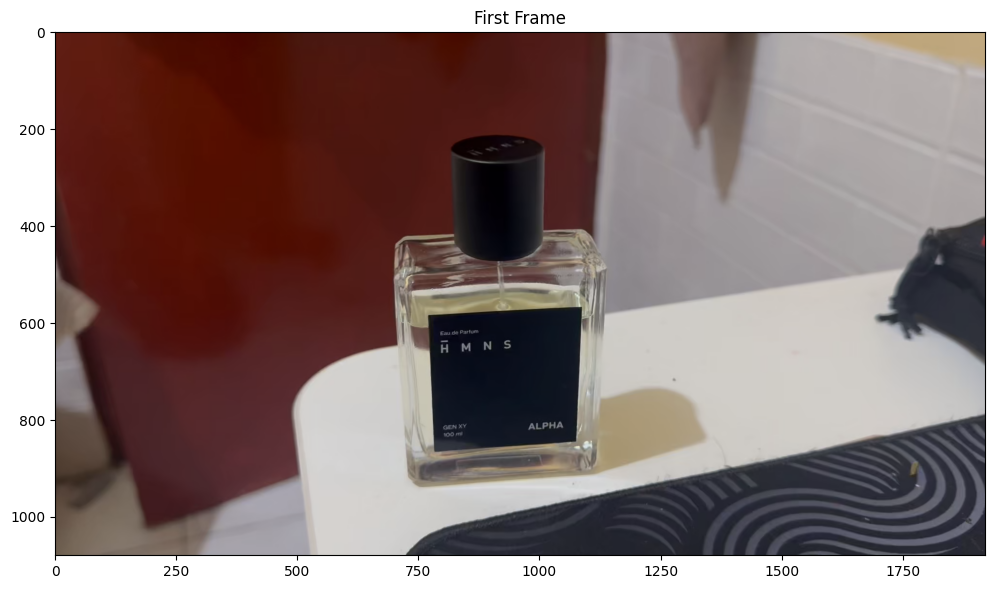

In [53]:
frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.title("First Frame")
plt.axis("on")

In [55]:
x = 740
y = 540

w = 300
h = 320

template = frame_rgb[y:y+h, x:x+w]

# =========================
# VIDEO WRITER
# =========================
fps = cap.get(cv2.CAP_PROP_FPS)

if fps == 0:
    fps = 30

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'XVID')

out = cv2.VideoWriter(
    TEMP_OUTPUT,
    fourcc,
    fps,
    (frame_width, frame_height)
)

if not out.isOpened():
    raise Exception("VideoWriter failed")

# RESET FRAME POSITION
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

True

In [56]:
import subprocess
import os
from IPython.display import Video

frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # =================================
    # FRAME TO GRAYSCALE
    # =================================

    gray_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    # =================================
    # TEMPLATE MATCHING
    # =================================

    result = cv2.matchTemplate(
        gray_frame,
        gray_template,
        cv2.TM_CCOEFF_NORMED
    )

    _, max_val, _, max_loc = cv2.minMaxLoc(result)

    top_left = max_loc

    bottom_right = (
        top_left[0] + w,
        top_left[1] + h
    )

    # =================================
    # DRAW RECTANGLE
    # =================================

    cv2.rectangle(
        frame,
        top_left,
        bottom_right,
        (0, 255, 0),
        3
    )

    # =================================
    # CONFIDENCE TEXT
    # =================================

    cv2.putText(
        frame,
        f"Confidence: {max_val:.2f}",
        (20, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # =================================
    # METHOD LABEL
    # =================================

    cv2.putText(
        frame,
        "Template Matching",
        (20, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        2
    )

    # =================================
    # SAVE FRAME
    # =================================

    out.write(frame)

    frame_count += 1

# =====================================
# RELEASE
# =====================================

cap.release()
out.release()

print(f"Finished processing {frame_count} frames")

# =====================================
# CONVERT AVI -> MP4
# =====================================

cmd = [
    "ffmpeg",
    "-y",
    "-i",
    TEMP_OUTPUT,
    "-vcodec",
    "libx264",
    "-pix_fmt",
    "yuv420p",
    FINAL_OUTPUT
]

result = subprocess.run(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

if result.returncode != 0:
    print("FFmpeg conversion failed")
    print(result.stderr.decode())
else:
    print(f"MP4 saved to: {FINAL_OUTPUT}")

# =====================================
# DELETE TEMP FILE
# =====================================

if os.path.exists(TEMP_OUTPUT):
    os.remove(TEMP_OUTPUT)
    print("Temporary AVI deleted")

# =====================================
# PREVIEW VIDEO
# =====================================

Video(FINAL_OUTPUT, embed=True)

Finished processing 468 frames
MP4 saved to: ./output/template_static.mp4
Temporary AVI deleted
